### Silnik DC

In [4]:
import numpy as np
from control import StateSpace, forced_response

# Parametry fizyczne silnika DC
J = 0.01  # moment bezwładności [kg·m²]
b = 0.1   # współczynnik tarcia [N·m·s/rad]
K = 0.01  # stała elektromechaniczna [N·m/A = V·s/rad]
R = 1.0   # rezystancja uzwojenia [Ω]
L = 0.5   # indukcyjność uzwojenia [H]

# Macierze modelu w przestrzeni stanów
# Stan: x = [ω, i]^T, gdzie ω – prędkość kątowa [rad/s], i – prąd uzwojenia [A]
A = np.array([[-b/J, K/J],
              [-K/L, -R/L]])
B = np.array([[0],
              [1/L]])
C = np.array([1, 0])  # Wyjście: prędkość kątowa ω
D = np.array([[0]])   # Brak przejścia bezpośredniego

# Tworzenie modelu StateSpace
motor = StateSpace(A, B, C, D)

# Symulacja odpowiedzi na skok napięcia wejściowego (1 V)
t = np.linspace(0, 5, 1000)
u = np.ones_like(t)  # Sygnał wejściowy: stałe napięcie 1 V

# Obliczenie odpowiedzi wymuszonej
t_out, y_out = forced_response(motor, T=t, U=u)


print(f"Wartosc ustalona: {y_out[-1]:.4f} rad/s")
print(f"Stala czasowa tau_e = L/R = {L/R:.2f} s")


Wartosc ustalona: 0.0999 rad/s
Stala czasowa tau_e = L/R = 0.50 s


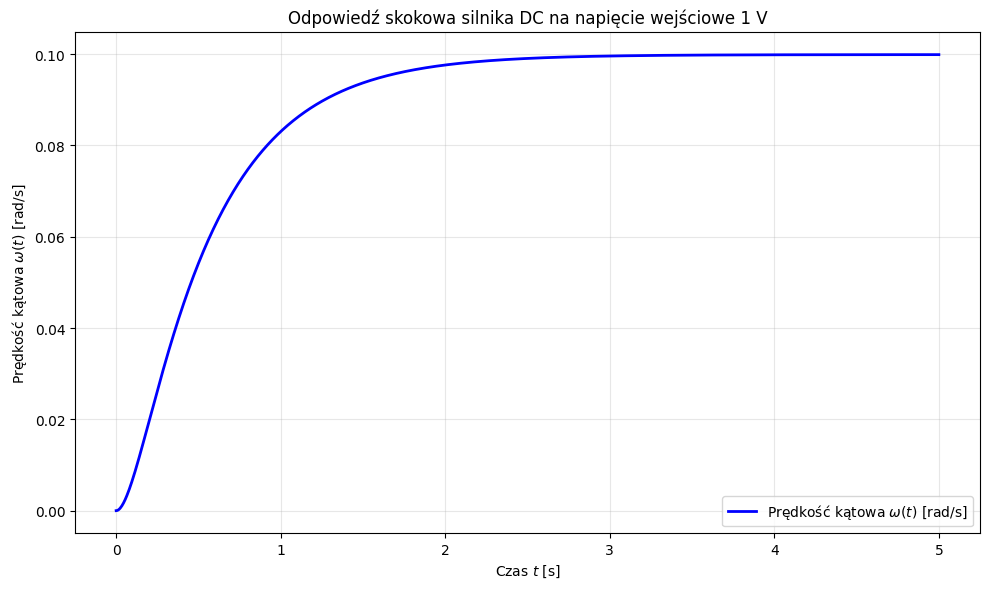

In [5]:
import matplotlib.pyplot as plt

# Wizualizacja wyników
plt.figure(figsize=(10, 6))
plt.plot(t_out, y_out, 'b-', linewidth=2, label='Prędkość kątowa $\omega(t)$ [rad/s]')
plt.xlabel('Czas $t$ [s]')
plt.ylabel('Prędkość kątowa $\omega(t)$ [rad/s]')
plt.title('Odpowiedź skokowa silnika DC na napięcie wejściowe 1 V')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()